# Training the `TrajectoryLSTM` (temporal split, displacement target)

Pipeline to train an LSTM that predicts volleyball player trajectories:

1. Extract trajectories from the video using **YOLO + ByteTrack**.
2. Build windows (`SEQ_LEN` input frames -> `PRED_LEN` frames to predict) with a
   **temporal split** (first 80% of each trajectory -> train, last 20% -> val), so the
   model is trained on the PAST of each trajectory and validated on its FUTURE.
3. Train the `TrajectoryLSTM` and evaluate it against a naive baseline.

**Target = displacement (Δ).** The model predicts
`Δ = future_position − last_observed_position` instead of absolute coordinates. The naive
baseline is therefore "Δ = 0" (stay put), so the model only improves on it if it predicts
real motion.

**Temporal resolution.** `SUBSAMPLE` keeps 1 of every k frames; with more movement between
steps, "stay put" becomes a worse predictor and the LSTM has room to show it learns
dynamics. `PRED_LEN` controls how far ahead the model predicts.

## 1. Install dependencies

In [1]:
# Installs all required dependencies in a fresh Colab
!pip install -q ultralytics supervision opencv-python-headless
print('OK dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
OK dependencies installed


## 2. Imports and configuration

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DEVICE = {DEVICE}')

DEVICE = cuda


## 3. Model architecture: `TrajectoryLSTM`

2-layer bidirectional LSTM. The output now represents **displacements (Δx, Δy)**
relative to the last observed position, not absolute coordinates.

In [3]:
class TrajectoryLSTM(nn.Module):
    """
    2-layer bidirectional LSTM for trajectory prediction.
    Input:  (batch, seq=20, 5)  -- x, y, vx, vy, conf per frame
    Output: (batch, pred=10, 2) -- future DISPLACEMENTS (dx, dy) w.r.t. last frame
    """
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, pred_len=10, dropout=0.3):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.predictor = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.ReLU(True),
            nn.Dropout(dropout), nn.Linear(64, pred_len * 2)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.predictor(out[:, -1, :]).view(-1, self.pred_len, 2)

print('Architecture defined: TrajectoryLSTM (delta output)')

Architecture defined: TrajectoryLSTM (delta output)


## 4. YOLO detection (`yolo_detect`)

Helper that runs YOLO on a frame and separates players from the ball.

In [4]:
def yolo_detect(image_bgr, yolo_model, person_conf=0.35, ball_conf=0.15,
                min_person_height=60):
    H_f, W_f = image_bgr.shape[:2]
    results = yolo_model.predict(image_bgr, conf=min(person_conf, ball_conf),
                                 verbose=False, device=DEVICE)[0]
    players, balls = [], []
    if results.boxes is None or len(results.boxes) == 0:
        return players, balls
    for box in results.boxes:
        cls_id = int(box.cls[0])
        score = float(box.conf[0])
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        h = y2 - y1
        cls_name = yolo_model.names.get(cls_id, str(cls_id))
        # Person / player
        if cls_name in ('player', 'person') and score >= person_conf:
            if h < min_person_height:
                continue
            players.append({
                'box': np.array([x1, y1, x2, y2]),
                'cx': cx, 'cy': cy, 'cx_n': cx / W_f, 'cy_n': cy / H_f,
                'score': score, 'conf': score, 'class_name': cls_name
            })
        # Ball
        elif cls_name in ('ball', 'volleyball') and score >= ball_conf:
            balls.append({
                'box': np.array([x1, y1, x2, y2]),
                'cx': cx, 'cy': cy, 'cx_n': cx / W_f, 'cy_n': cy / H_f,
                'score': score, 'conf': score, 'class_name': cls_name
            })
    return players, balls

print('Function defined: yolo_detect')

Function defined: yolo_detect


## 5. Load the YOLO person model

In [5]:
from ultralytics import YOLO

yolo_persons = YOLO('/content/volleyball_persons_best.pt')
print(f'YOLO persons loaded: {yolo_persons.names}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO persons loaded: {0: 'player'}


## 6. Extract trajectories from the video (YOLO + ByteTrack)

Iterates over the video, tracks each player with ByteTrack and saves the
normalized trajectories to `trajectories.npz`.

In [6]:
import supervision as sv

VIDEO_PATH = '/content/video.mp4'
TRAJ_OUTPUT = 'trajectories.npz'
MIN_TRAJ_LEN = 30

# Sanity check: if this fails, run the previous sections first
assert 'yolo_persons' in globals(), 'Missing yolo_persons -> run section 5'
assert 'yolo_detect' in globals(), 'Missing yolo_detect -> run section 4'
assert 'DEVICE' in globals(), 'Missing DEVICE -> run section 2'

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {total} frames @ {fps:.0f}fps ({total/fps:.1f}s)')

extract_tracker = sv.ByteTrack(
    track_activation_threshold=0.3,
    lost_track_buffer=30,
    minimum_matching_threshold=0.8,
)
extract_tracker.reset()

raw_tracks = defaultdict(list)
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    H_f, W_f = frame.shape[:2]

    players, _ = yolo_detect(
        frame, yolo_persons,
        person_conf=0.35, ball_conf=1.1, min_person_height=60
    )
    if not players:
        frame_idx += 1
        continue

    boxes = np.array([p['box'] for p in players])
    scores = np.array([p['score'] for p in players])
    sv_dets = sv.Detections(
        xyxy=boxes, confidence=scores,
        class_id=np.zeros(len(players), dtype=int)
    )
    tracked = extract_tracker.update_with_detections(sv_dets)

    if tracked.tracker_id is not None:
        for i, box in enumerate(tracked.xyxy):
            x1, y1, x2, y2 = box
            cx_n = ((x1 + x2) / 2) / W_f
            cy_n = ((y1 + y2) / 2) / H_f
            conf = float(tracked.confidence[i]) if tracked.confidence is not None else 0.5
            tid = int(tracked.tracker_id[i])
            raw_tracks[tid].append((cx_n, cy_n, conf))

    frame_idx += 1
    if frame_idx % 100 == 0:
        print(f'  {frame_idx}/{total} ({100*frame_idx/total:.0f}%)')

cap.release()

trajectories = {tid: np.array(t, dtype=np.float32)
                for tid, t in raw_tracks.items() if len(t) >= MIN_TRAJ_LEN}

print(f'\nTotal tracks: {len(raw_tracks)}')
print(f'Useful tracks (>={MIN_TRAJ_LEN} frames): {len(trajectories)}')
print(f'Total frames in useful tracks: {sum(len(t) for t in trajectories.values())}')

np.savez(TRAJ_OUTPUT, **{f'track_{tid}': t for tid, t in trajectories.items()})
print(f'OK saved to {TRAJ_OUTPUT}')

Video: 258 frames @ 30fps (8.6s)


  100/258 (39%)
  200/258 (78%)

Total tracks: 100
Useful tracks (>=30 frames): 28
Total frames in useful tracks: 3315
OK saved to trajectories.npz


## 7. Build windows and train the LSTM (temporal split, Δ target)

The **target is the displacement** from the last observed frame,
`Δ = future_position − last_position`, so the naive "stay put" prediction corresponds to
`Δ = 0`. The temporal split and train-only augmentation (horizontal flip + light noise)
keep the validation set clean. At the end the model is compared against the naive baseline
on the exact same validation set.

TEMPORAL split | target = displacement (delta) | SUBSAMPLE=4 | PRED_LEN=10
Train: (468, 20, 5) -> (468, 10, 2)
Val:   (56, 20, 5) -> (56, 10, 2)
Epoch   1/50 | train MSE=0.00471 | val MSE=0.00154
Epoch   6/50 | train MSE=0.00187 | val MSE=0.00106
Epoch  11/50 | train MSE=0.00162 | val MSE=0.00105
Epoch  16/50 | train MSE=0.00149 | val MSE=0.00106
Epoch  21/50 | train MSE=0.00148 | val MSE=0.00111
Epoch  26/50 | train MSE=0.00143 | val MSE=0.00113
Epoch  31/50 | train MSE=0.00140 | val MSE=0.00110
Epoch  36/50 | train MSE=0.00139 | val MSE=0.00109
Epoch  41/50 | train MSE=0.00142 | val MSE=0.00108
Epoch  46/50 | train MSE=0.00138 | val MSE=0.00109
Epoch  50/50 | train MSE=0.00138 | val MSE=0.00110

Best LSTM val MSE:                0.00105
Naive (stay put, delta=0) val MSE: 0.00116
-> LSTM BEATS the naive baseline by 10.0% (it learns real motion).
Model saved to best_lstm_tracker.pth


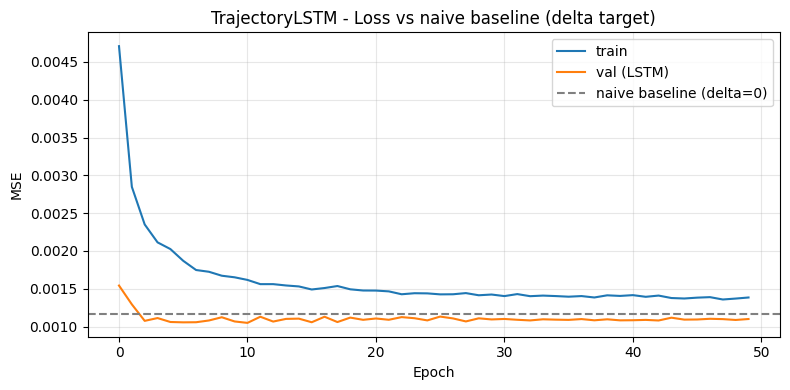

In [10]:
SEQ_LEN = 20
PRED_LEN = 10
STRIDE = 1
TRAIN_RATIO = 0.8   # first 80% of each trajectory -> train, rest -> val
SUBSAMPLE = 4       # keep 4 of every k frames (1 = off). Raise to 3-5 for more motion.


def trajectory_to_windows_temporal(traj, seq_len=20, pred_len=10, stride=1,
                                    train_ratio=0.8):
    """
    Turns a trajectory (N, 3) into (input, target) pairs with a TEMPORAL split.
    The TARGET is the DISPLACEMENT relative to the last observed frame:
        y = future_positions - last_input_position
    so the naive "stay put" prediction corresponds to y = 0.
    The first N*train_ratio windows go to train, the rest to val.
    """
    N = len(traj)
    if N < seq_len + pred_len:
        return [], [], [], []

    vx = np.zeros(N, dtype=np.float32)
    vy = np.zeros(N, dtype=np.float32)
    vx[1:] = traj[1:, 0] - traj[:-1, 0]
    vy[1:] = traj[1:, 1] - traj[:-1, 1]
    full = np.stack([traj[:, 0], traj[:, 1], vx, vy, traj[:, 2]], axis=1)

    inputs, targets = [], []
    for i in range(0, N - seq_len - pred_len + 1, stride):
        x = full[i:i+seq_len]
        last_pos = full[i+seq_len-1, :2]                       # last observed position
        future = full[i+seq_len:i+seq_len+pred_len, :2]        # absolute future positions
        y = future - last_pos                                  # <-- DISPLACEMENT target
        inputs.append(x)
        targets.append(y)

    # Temporal split: first windows -> train, last ones -> val
    n_train_windows = int(len(inputs) * train_ratio)
    X_tr = inputs[:n_train_windows]
    Y_tr = targets[:n_train_windows]
    X_va = inputs[n_train_windows:]
    Y_va = targets[n_train_windows:]
    return X_tr, Y_tr, X_va, Y_va


def build_temporal_dataset(trajectories, augment_train=True):
    """
    Iterates over all trajectories, optionally subsamples frames, and applies a
    temporal split to each one. Augmentation (flip + noise) is applied ONLY to the
    train block so the validation set is not contaminated.
    """
    X_train, Y_train, X_val, Y_val = [], [], [], []
    for tid, traj in trajectories.items():
        traj = traj[::SUBSAMPLE]            # subsample frames (1 = no change)
        N = len(traj)
        if N < SEQ_LEN + PRED_LEN:
            continue

        xt, yt, xv, yv = trajectory_to_windows_temporal(
            traj, SEQ_LEN, PRED_LEN, STRIDE, TRAIN_RATIO
        )
        X_train.extend(xt); Y_train.extend(yt)
        X_val.extend(xv);   Y_val.extend(yv)

        if augment_train:
            n_tr_frames = int(N * TRAIN_RATIO)
            if n_tr_frames < SEQ_LEN + PRED_LEN:
                continue

            # 1) Horizontal flip (court symmetry), train only
            traj_flip = traj[:n_tr_frames].copy()
            traj_flip[:, 0] = 1.0 - traj_flip[:, 0]
            xt2, yt2, _, _ = trajectory_to_windows_temporal(
                traj_flip, SEQ_LEN, PRED_LEN, STRIDE, train_ratio=1.0
            )
            X_train.extend(xt2); Y_train.extend(yt2)

            # 2) Light Gaussian noise, train only
            traj_noise = traj[:n_tr_frames].copy()
            traj_noise[:, :2] += np.random.randn(*traj_noise[:, :2].shape) * 0.003
            xt3, yt3, _, _ = trajectory_to_windows_temporal(
                traj_noise, SEQ_LEN, PRED_LEN, STRIDE, train_ratio=1.0
            )
            X_train.extend(xt3); Y_train.extend(yt3)

    return (np.array(X_train, dtype=np.float32),
            np.array(Y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32),
            np.array(Y_val, dtype=np.float32))


X_train, Y_train, X_val, Y_val = build_temporal_dataset(trajectories, augment_train=True)
print(f'TEMPORAL split | target = displacement (delta) | SUBSAMPLE={SUBSAMPLE} | PRED_LEN={PRED_LEN}')
print(f'Train: {X_train.shape} -> {Y_train.shape}')
print(f'Val:   {X_val.shape} -> {Y_val.shape}')


class TrajDS(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X); self.Y = torch.tensor(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


train_dl = DataLoader(TrajDS(X_train, Y_train), batch_size=64, shuffle=True)
val_dl   = DataLoader(TrajDS(X_val, Y_val), batch_size=64)

LSTM_WEIGHTS = 'best_lstm_tracker.pth'
lstm_train = TrajectoryLSTM(input_size=5, hidden_size=128,
                            num_layers=2, pred_len=PRED_LEN, dropout=0.3).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_train.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

EPOCHS = 50
tr_losses, va_losses = [], []
best_val = float('inf')

for epoch in range(EPOCHS):
    lstm_train.train()
    tl = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = lstm_train(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        tl += loss.item() * len(xb)
    tl /= len(X_train)
    tr_losses.append(tl)

    lstm_train.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += criterion(lstm_train(xb), yb).item() * len(xb)
    vl /= len(X_val)
    va_losses.append(vl)

    if vl < best_val:
        best_val = vl
        torch.save(lstm_train.state_dict(), LSTM_WEIGHTS)

    scheduler.step()
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch+1:3}/{EPOCHS} | train MSE={tl:.5f} | val MSE={vl:.5f}')

# ---- Naive baseline: predict zero displacement ("stay put") ----
naive_val_mse = float((Y_val ** 2).mean())

print(f'\nBest LSTM val MSE:                {best_val:.5f}')
print(f'Naive (stay put, delta=0) val MSE: {naive_val_mse:.5f}')
improvement = 100 * (naive_val_mse - best_val) / naive_val_mse
if best_val < naive_val_mse:
    print(f'-> LSTM BEATS the naive baseline by {improvement:.1f}% (it learns real motion).')
else:
    print(f'-> LSTM does NOT beat naive ({improvement:.1f}%): trajectories are near-static.')
    print('   Try raising SUBSAMPLE (e.g. 3-5) and/or PRED_LEN, then re-run section 7.')
print(f'Model saved to {LSTM_WEIGHTS}')

plt.figure(figsize=(8, 4))
plt.plot(tr_losses, label='train')
plt.plot(va_losses, label='val (LSTM)')
plt.axhline(naive_val_mse, color='gray', ls='--', label='naive baseline (delta=0)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('TrajectoryLSTM - Loss vs naive baseline (delta target)')
plt.tight_layout(); plt.savefig('lstm_loss_curve.png', dpi=120); plt.show()

## 8. Visual evaluation of predictions

The model outputs displacements, so we reconstruct absolute positions as
`absolute = last_observed_position + Δ` before plotting. Shows the 4 validation
samples with the most movement: past, ground truth and prediction.

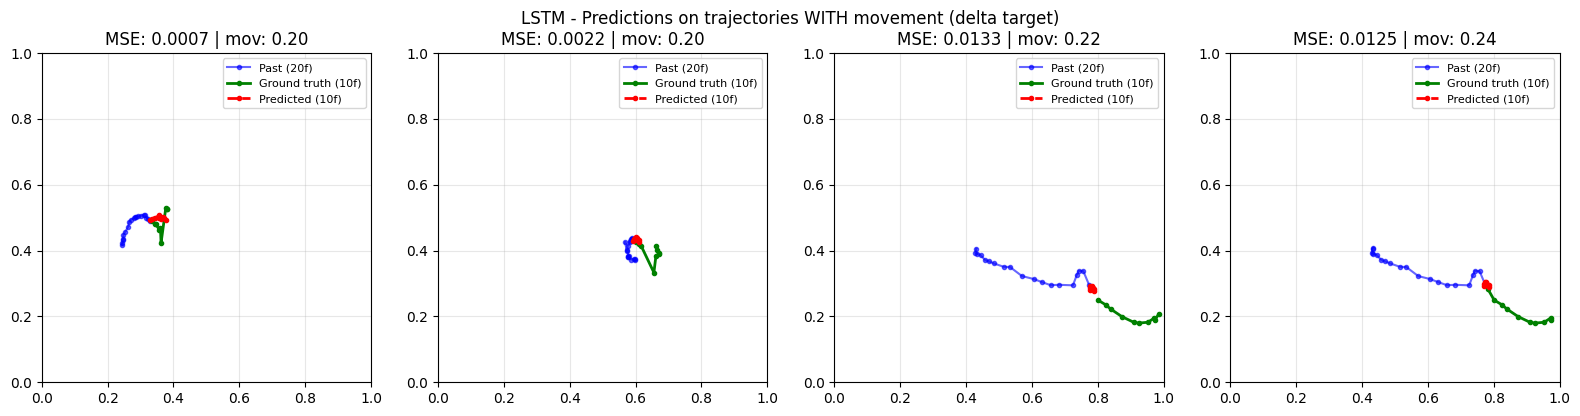

In [11]:
lstm_train.load_state_dict(torch.load(LSTM_WEIGHTS, map_location=DEVICE))
lstm_train.eval()

# How much each val sample moves (path length of the future, in delta space)
movements = []
for i in range(len(X_val)):
    disp = np.sum(np.linalg.norm(np.diff(Y_val[i], axis=0), axis=1))
    movements.append(disp)
movements = np.array(movements)

# Take the 4 samples with the MOST movement
n_show = 4
idxs = np.argsort(movements)[-n_show:]   # top 4 by displacement

fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
with torch.no_grad():
    for ax, idx in zip(axes, idxs):
        x = torch.tensor(X_val[idx:idx+1]).to(DEVICE)
        last_pos = X_val[idx, -1, :2]                       # last observed position
        y_pred_delta = lstm_train(x)[0].cpu().numpy()
        y_pred = last_pos + y_pred_delta                    # reconstruct absolute
        y_true = last_pos + Y_val[idx]                      # reconstruct absolute
        past = X_val[idx, :, :2]

        ax.plot(past[:, 0], 1 - past[:, 1], 'b.-', label='Past (20f)', alpha=0.6)
        ax.plot(y_true[:, 0], 1 - y_true[:, 1], 'g.-', label='Ground truth (10f)', linewidth=2)
        ax.plot(y_pred[:, 0], 1 - y_pred[:, 1], 'r.--', label='Predicted (10f)', linewidth=2)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
        mse = ((y_pred_delta - Y_val[idx]) ** 2).mean()
        ax.set_title(f'MSE: {mse:.4f} | mov: {movements[idx]:.2f}')

plt.suptitle('LSTM - Predictions on trajectories WITH movement (delta target)')
plt.tight_layout(); plt.savefig('lstm_predictions_sample.png', dpi=120); plt.show()

## 9. Download results

In [9]:
from google.colab import files

# List what is in /content to confirm
print('Files in /content:')
for f in sorted(os.listdir('/content')):
    size_kb = os.path.getsize(f'/content/{f}') / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')

# Downloads
files.download('/content/best_lstm_tracker.pth')
files.download('/content/lstm_loss_curve.png')
files.download('/content/lstm_predictions_sample.png')
files.download('/content/trajectories.npz')

Files in /content:
  .config  (4.0 KB)
  best_lstm_tracker.pth  (2157.6 KB)
  lstm_loss_curve.png  (42.4 KB)
  lstm_predictions_sample.png  (44.2 KB)
  sample_data  (4.0 KB)
  trajectories.npz  (45.6 KB)
  video.mp4  (21293.0 KB)
  volleyball_persons_best.pt  (21987.8 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>